In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, ridge_regression

from xgboost import XGBRegressor

<h2 align="center" style="color:Green">Data Loading</h2>

In [86]:
df = pd.read_excel(r"D:\AI-engineer Study\Projects\Project 7 Premium Prediction ver1\data\premiums_young_with_gr.xlsx")
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [87]:
df.shape

(20096, 14)

In [88]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='str')

In [89]:
df.columns.str.replace(" ", "_").str.lower()

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='str')

In [90]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [91]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='str')

<h2 align="center" style="color:green">Exploratory Data Analysis & Data Cleaning</h2>

### Handle missing values

In [92]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [93]:
df.dropna(inplace=True)
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handle duplicate

In [94]:
if df.duplicated().sum() > 0:
    print(f"Before drop duplicate: {df.duplicated().sum()}")
    df.drop_duplicates(inplace=True)
    print(f"After drop duplicate: {df.duplicated().sum()}")
else:
    print(f"No duplicate: {df.duplicated().sum()}")

No duplicate: 0


In [95]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


#### Data Cleaning: number_of_dependants

In [96]:
df.loc[df['number_of_dependants'] < 0]['number_of_dependants'].unique()

array([-3, -1])

We can see some negative values in number_of_dependants. We can replace them with positive numbers

In [97]:
df['number_of_dependants'] = np.abs(df['number_of_dependants'])

In [98]:
df.loc[df['number_of_dependants'] < 0]['number_of_dependants'].unique()

array([], dtype=int64)

In [99]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267,2.503932
std,2.294052,0.937200,23.420493,2749.906347,1.710203
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


## 1. Numeric Columns
### Univariate Analysis: Numeric Columns
#### Box plots for numeric columns

In [100]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='str')

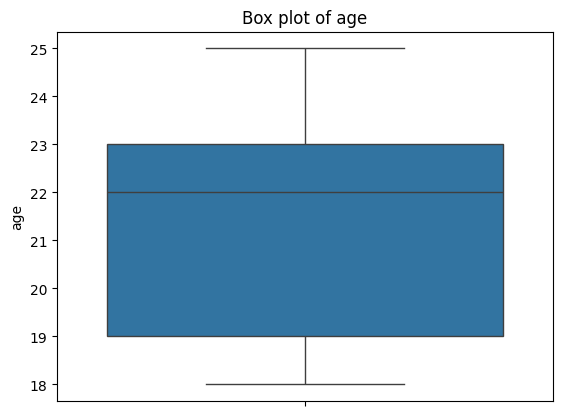

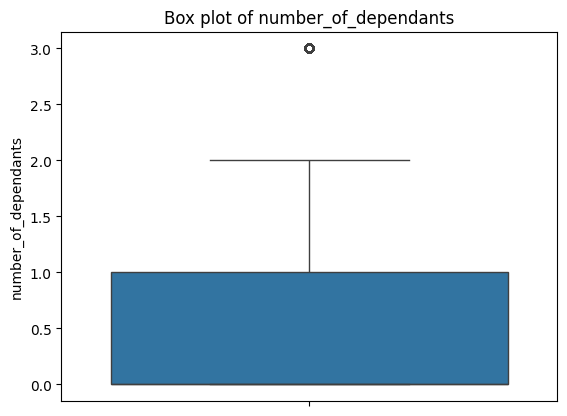

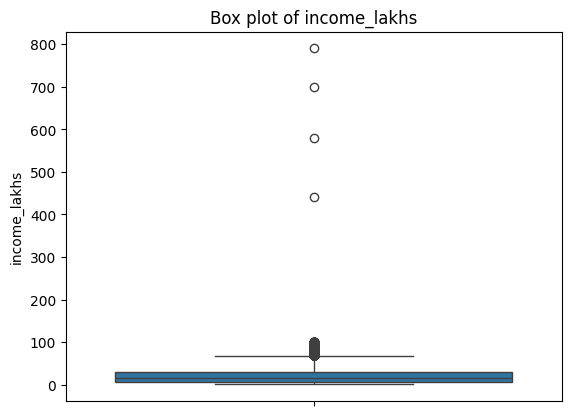

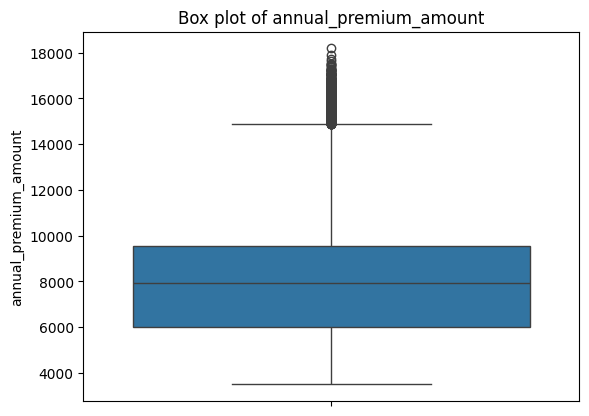

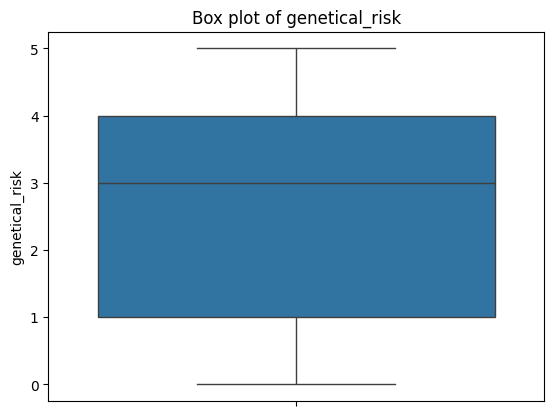

In [101]:
for col in numeric_columns:
    sns.boxplot(data=df, y=col)
    plt.title(f"Box plot of {col}")
    plt.show()

### Outlier Treatment: Age Column

In [102]:
df.loc[df['age'] > 100]['age'].unique()

array([], dtype=int64)

In [103]:
df.loc[df['age'] > 100].shape[0]

0

In [104]:
df1 = df.loc[df['age'] <= 100]
df1.shape[0]

20090

In [105]:
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267,2.503932
std,2.294052,0.937200,23.420493,2749.906347,1.710203
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


### Outlier Treatment: Income Column

In [106]:
def get_iqr_bound(col):
    q1, q3 = col.quantile([0.25, 0.75])
    IQR = q3 - q1
    upper_bound = q3 + (1.5 * IQR)
    lower_bound = q1 - (1.5 * IQR)
    return lower_bound, upper_bound

lower, upper = get_iqr_bound(df1['income_lakhs'])
lower, upper

(-31.5, 68.5)

In [107]:
df1.loc[df1['income_lakhs'] > upper].shape[0]

1295

There are many legitimate records that we will get rid of if we use IQR bounds method. Hence after discussion with business we decided to use a simple quantile bound 

In [108]:
quantile_thresold = df1['income_lakhs'].quantile(0.999)
quantile_thresold

np.float64(100.0)

In [109]:
df1.loc[df1['income_lakhs'] > quantile_thresold].shape[0]

4

In [110]:
df2 = df1.loc[df1['income_lakhs'] <= quantile_thresold].copy()
df2.shape

(20086, 14)

In [111]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


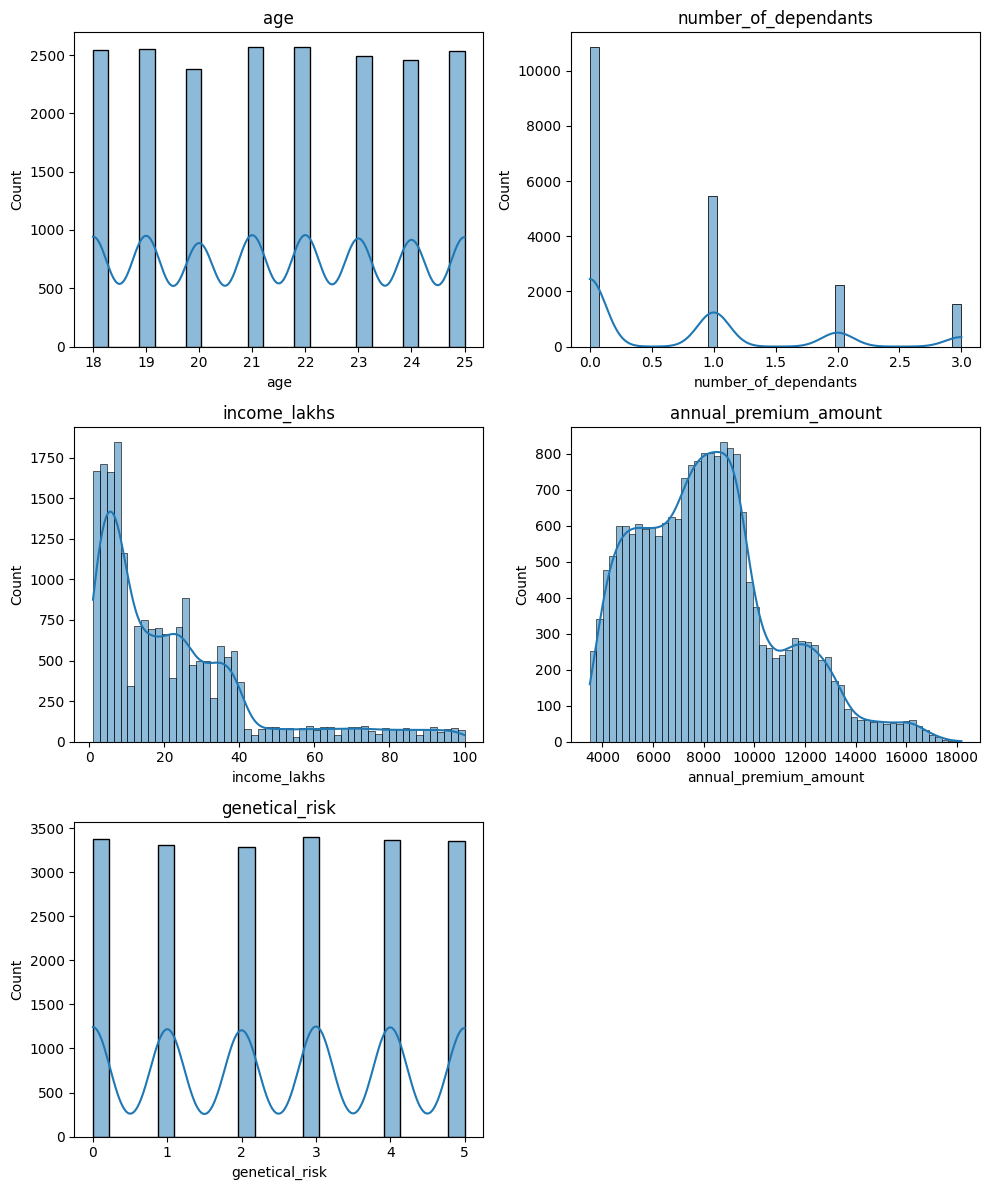

In [112]:
import math

# 1. Determine grid dimensions dynamically
ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows))

# 2. Flatten axs to a 1D array for simple 1D indexing
axs = axs.ravel()

# 3. Plot each numeric column
for i, column in enumerate(numeric_columns):
    sns.histplot(df2[column], kde=True, ax=axs[i])
    axs[i].set_title(column)

# 4. Hide empty subplots if numeric_columns is an odd count
for j in range(len(numeric_columns), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

### Bivariate Analysis: Numeric Columns

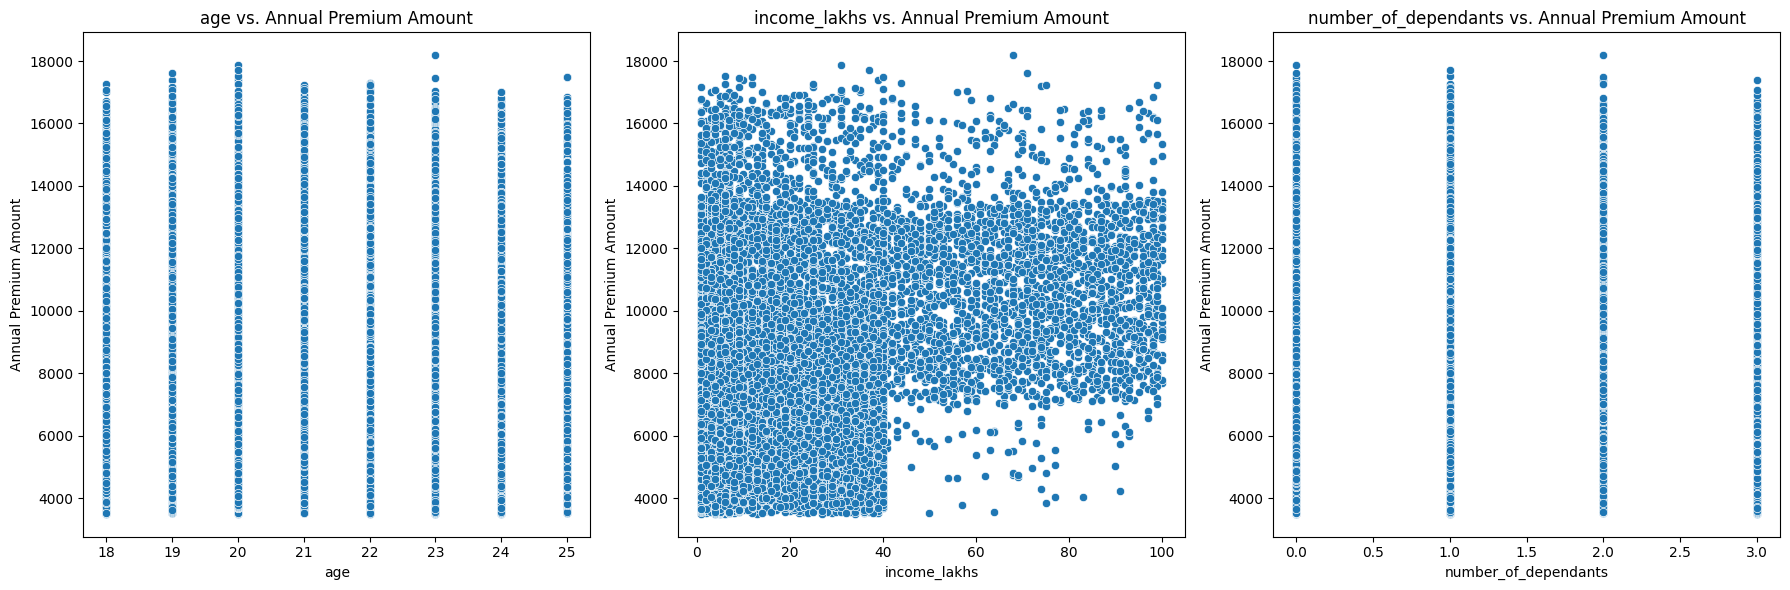

In [113]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

In [114]:
categorical_cols = df.select_dtypes(include=['str']).columns
print(categorical_cols)
len(categorical_cols)

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='str')


9

In [115]:
for col in categorical_cols:
    print(col, ": ", df2[col].unique())

gender :  <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
region :  <ArrowStringArray>
['Northeast', 'Northwest', 'Southeast', 'Southwest']
Length: 4, dtype: str
marital_status :  <ArrowStringArray>
['Unmarried', 'Married']
Length: 2, dtype: str
bmi_category :  <ArrowStringArray>
['Overweight', 'Underweight', 'Normal', 'Obesity']
Length: 4, dtype: str
smoking_status :  <ArrowStringArray>
[       'Regular',     'No Smoking',     'Occasional',      'Smoking=0',
 'Does Not Smoke',    'Not Smoking']
Length: 6, dtype: str
employment_status :  <ArrowStringArray>
['Self-Employed', 'Freelancer', 'Salaried']
Length: 3, dtype: str
income_level :  <ArrowStringArray>
['> 40L', '<10L', '10L - 25L', '25L - 40L']
Length: 4, dtype: str
medical_history :  <ArrowStringArray>
[                'High blood pressure',                          'No Disease',
      'Diabetes & High blood pressure',            'Diabetes & Heart disease',
                            'Diabetes',                  'Diab

In [116]:
df2.replace({'smoking_status':{
        'Not Smoking': 'No Smoking',
        'Does Not Smoke': 'No Smoking',
        'Smoking=0': 'No Smoking'
}}, inplace=True)

df2['smoking_status'].unique()

<ArrowStringArray>
['Regular', 'No Smoking', 'Occasional']
Length: 3, dtype: str

### Univariate Analysis

In [117]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [118]:
pct_count = df2['gender'].value_counts(normalize=True)*100
pct_count

gender
Male      55.038335
Female    44.961665
Name: proportion, dtype: float64

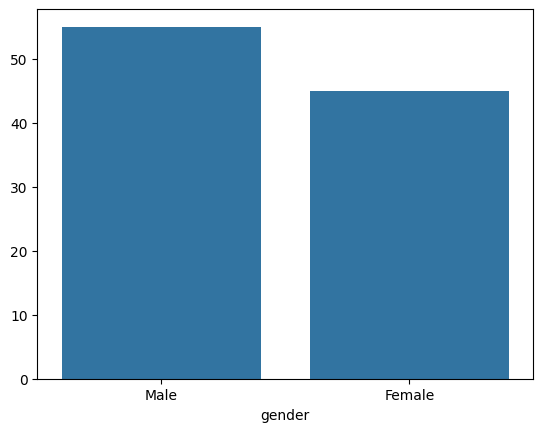

In [119]:
sns.barplot(x=pct_count.index, y=pct_count.values)
plt.show()

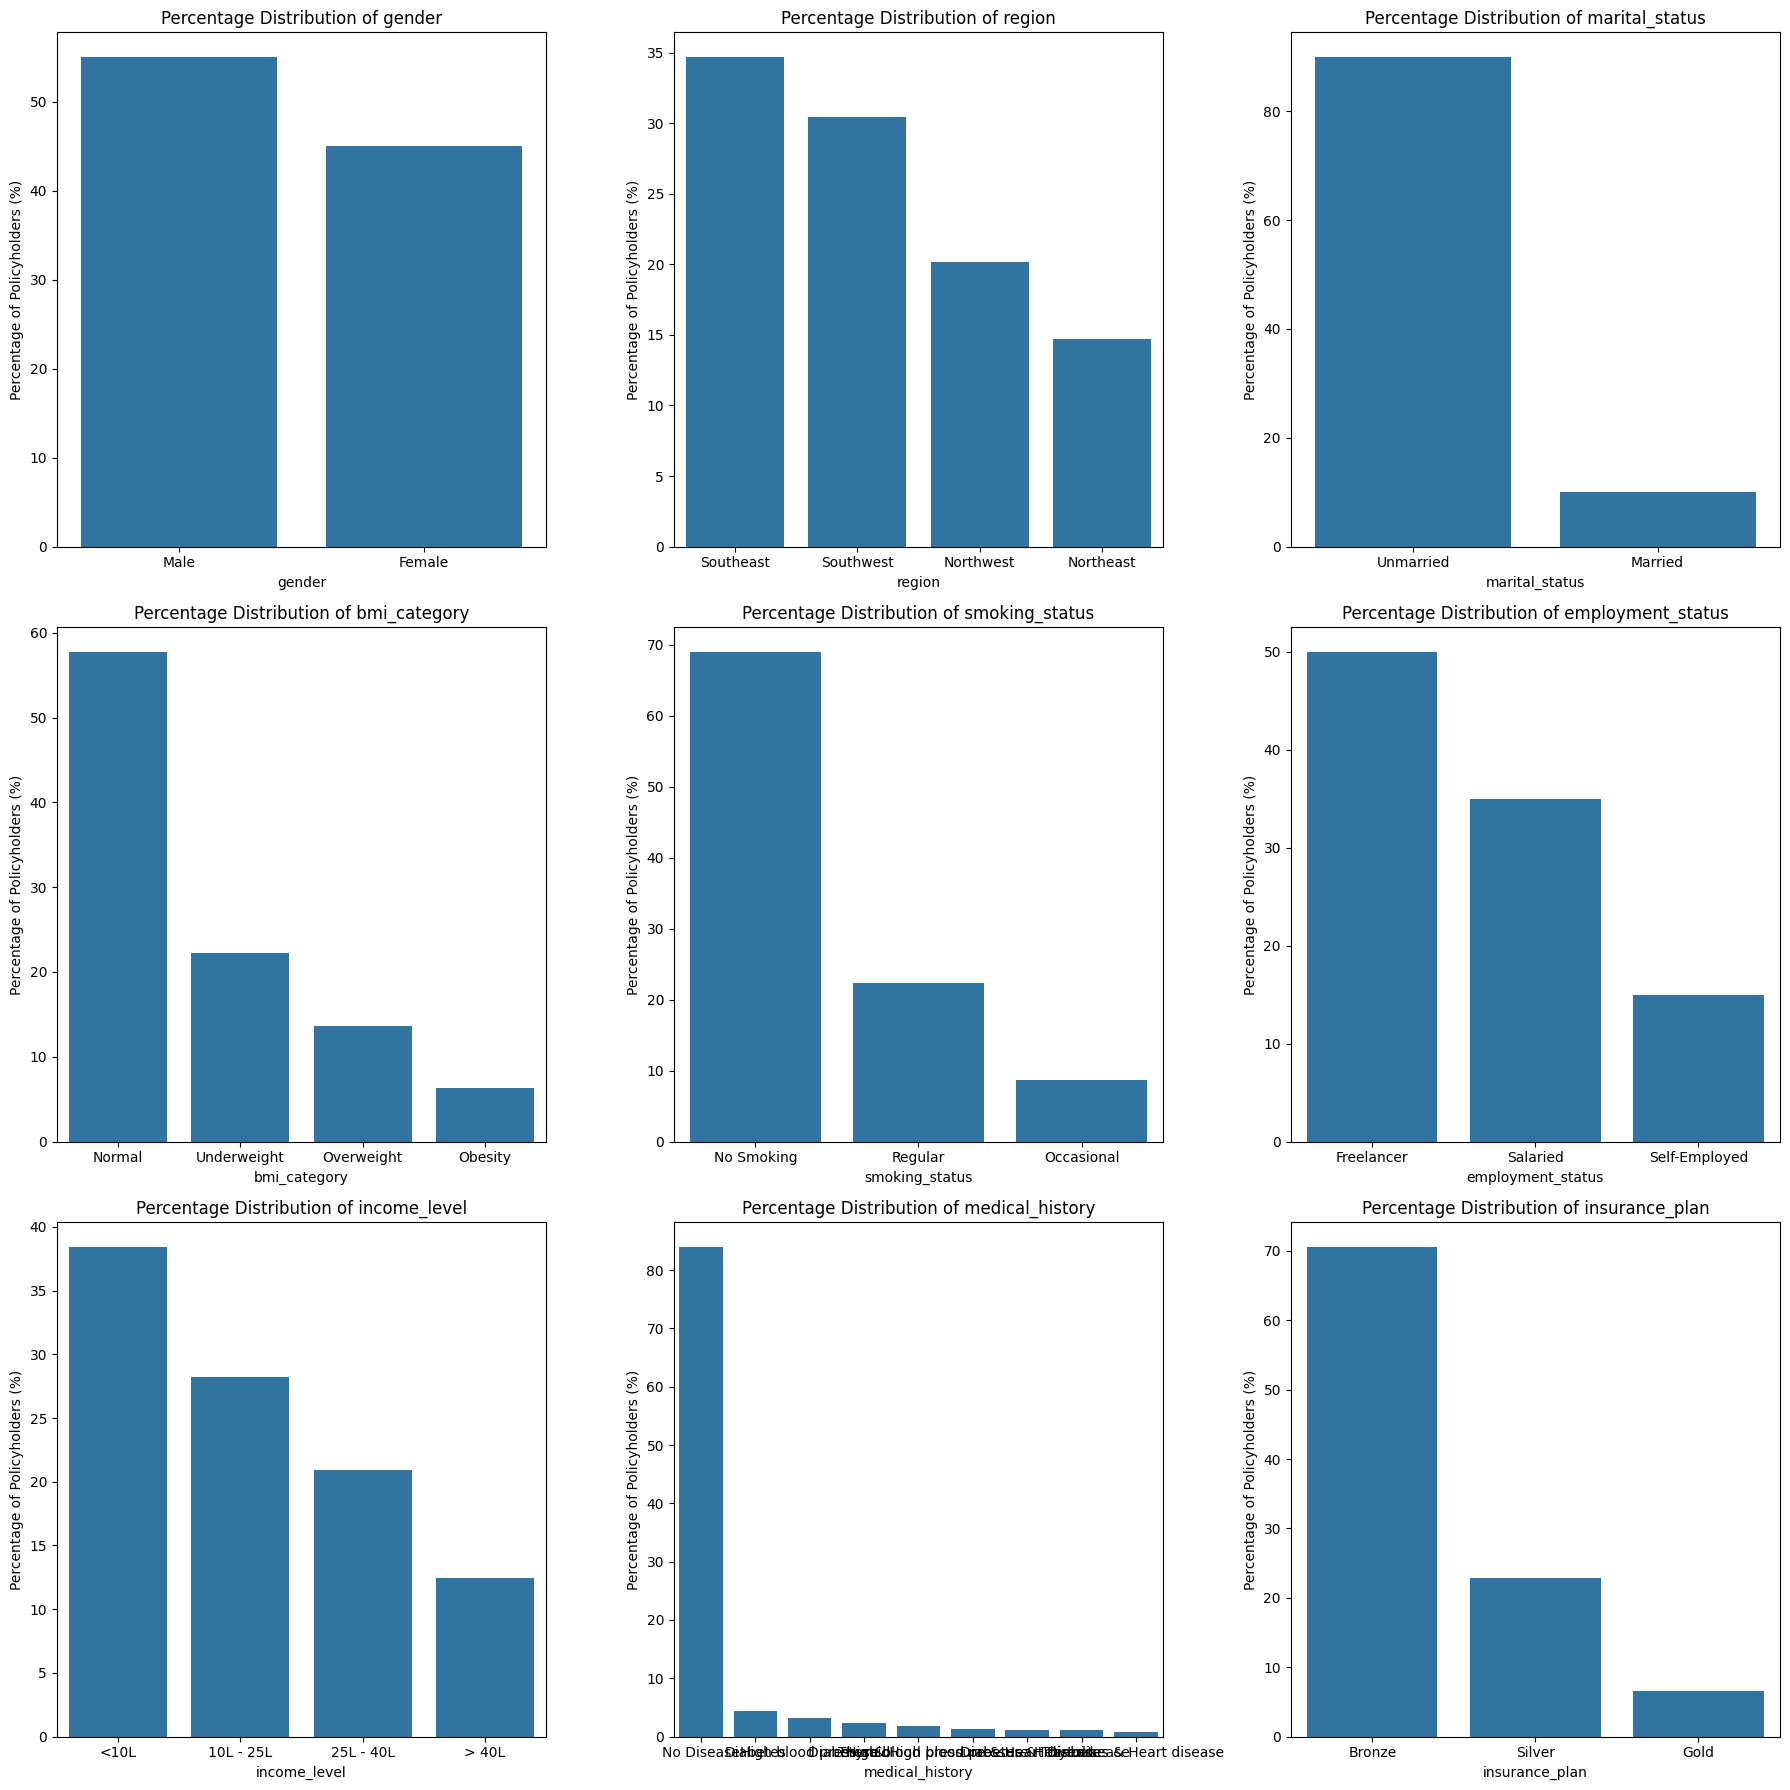

In [120]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

### Bivariate Analysis

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         4508   326     828
25L - 40L         3382   209     608
<10L              6172   404    1145
> 40L              115   366    2023


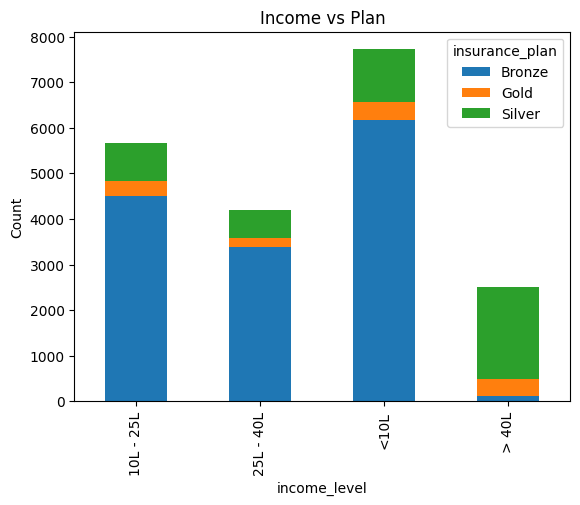

In [121]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

# Plotting the crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

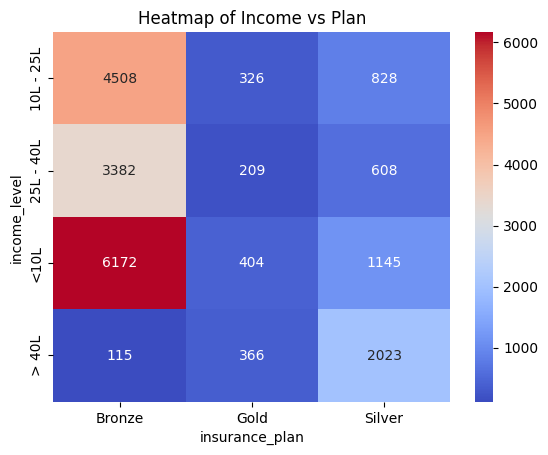

In [122]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

<h2 align="center" style="color:green">Feature Engineering</h2>

In [123]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [124]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [125]:
df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())

,0,1
0,high blood pressure,NaN
1,no disease,NaN
2,no disease,NaN
3,no disease,NaN
4,no disease,NaN
...,...,...
20091,no disease,NaN
20092,diabetes,NaN
20093,no disease,NaN
20094,no disease,NaN


### Split medical_history into 'disease1', 'disease2'

In [126]:
df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2[['disease1', 'disease2']].sample(5)

,disease1,disease2
3065,no disease,NaN
9424,no disease,NaN
3695,no disease,NaN
18383,no disease,NaN
7639,diabetes,NaN


In [127]:
# df2['disease1'].fillna("", inplace=True)
# df2['disease2'].fillna("", inplace=True)

df2.fillna({"disease1": "none"}, inplace=True)
df2.fillna({"disease2": "none"}, inplace=True)
df2[['disease1', 'disease2']].sample(5)

,disease1,disease2
14461,no disease,none
14630,no disease,none
12352,no disease,none
15848,no disease,none
4475,no disease,none


In [128]:
df2.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,none
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,none
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,none


### Adding column total_risk_score

In [129]:
df2['total_risk_score'] = 0

In [130]:
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

In [131]:
df2.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score
9375,25,Female,Southeast,Unmarried,1,Underweight,No Smoking,Freelancer,> 40L,93,High blood pressure,Silver,11744,4,high blood pressure,none,6
11269,19,Male,Northeast,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,17,High blood pressure,Bronze,6866,2,high blood pressure,none,6
1260,22,Male,Northwest,Married,2,Normal,No Smoking,Freelancer,25L - 40L,40,Diabetes,Silver,12696,5,diabetes,none,6
9838,22,Female,Southwest,Unmarried,1,Underweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,8042,4,no disease,none,0
17464,18,Male,Southwest,Unmarried,1,Normal,Regular,Self-Employed,> 40L,79,No Disease,Silver,13276,5,no disease,none,0


In [132]:
df2.shape

(20086, 17)

In [133]:
df3 = df2.drop(columns=['medical_history', 'disease1', 'disease2'])
df3.head()
df3.shape

(20086, 14)

In [134]:
X = df3.drop(columns=['annual_premium_amount'])
y = df3['annual_premium_amount']

In [135]:
X.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,genetical_risk,total_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,4,6
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,Silver,3,0
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,Silver,4,0
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,Bronze,2,0
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,Bronze,1,0


In [136]:
y.head()

0    13365
1    11050
2    11857
3     5684
4     5712
Name: annual_premium_amount, dtype: int64

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

# 1. Feature groupings
nominal_cols = [
    'gender', 'region', 'marital_status', 
    'bmi_category', 'smoking_status', 'employment_status'
]

# Raw numeric columns (do not include raw string columns here)
numeric_cols = ['age', 'number_of_dependants', 'income_lakhs', 'total_risk_score']

# 2. Category hierarchies
plan_order = ['Bronze', 'Silver', 'Gold']
income_order = ['<10L', '10L - 25L', '25L - 40L', '> 40L']

# 3. Pipelines to encode strings first, then scale numeric outputs
plan_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[plan_order])),
    ('scaler', MinMaxScaler())
])

income_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[income_order])),
    ('scaler', MinMaxScaler())
])

# 4. ColumnTransformer setup
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('plan_pipeline', plan_pipeline, ['insurance_plan']),
        ('income_pipeline', income_pipeline, ['income_level']),
        ('numeric_scaler', MinMaxScaler(), numeric_cols)  # Passed directly without extra brackets
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas')

X_train_processed = preprocessor.fit_transform(X_train)

In [139]:
X_train_processed.head()

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,age,number_of_dependants,income_lakhs,total_risk_score,genetical_risk
3829,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.666667,0.428571,0.000000,0.292929,0.0,4
15499,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.428571,1.000000,0.010101,0.0,1
6306,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.666667,0.857143,0.000000,0.363636,0.0,2
14010,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.571429,0.333333,0.050505,0.0,0
13819,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.571429,0.000000,0.050505,0.0,3


In [140]:
X_test_processed = preprocessor.transform(X_test)
X_test_processed

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,income_level,age,number_of_dependants,income_lakhs,total_risk_score,genetical_risk
10489,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.428571,1.000000,0.080808,0.428571,1
7989,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.714286,0.000000,0.030303,1.000000,4
3113,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.666667,0.142857,0.000000,0.363636,1.000000,0
10605,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.5,1.000000,0.428571,0.000000,0.515152,0.428571,4
4204,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.333333,0.000000,0.000000,0.222222,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18960,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.428571,0.333333,0.181818,0.000000,0
266,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.857143,0.333333,0.000000,0.000000,1
10036,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.000000,0.857143,0.000000,0.060606,0.000000,4
15506,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.571429,1.000000,0.686869,0.357143,2


In [141]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [142]:
calculate_vif(X_train_processed)

,Column,VIF
0,gender_Male,2.307954
1,region_Northwest,2.176789
2,region_Southeast,2.963829
3,region_Southwest,2.740467
4,marital_status_Unmarried,8.044267
5,bmi_category_Obesity,1.115150
6,bmi_category_Overweight,1.231103
7,bmi_category_Underweight,1.373569
8,smoking_status_Occasional,1.133403
9,smoking_status_Regular,1.387821


In [143]:
X_train_processed_final = X_train_processed.drop(columns=['income_level'])
X_train_processed_final.columns


Index(['gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed',
       'insurance_plan', 'age', 'number_of_dependants', 'income_lakhs',
       'total_risk_score', 'genetical_risk'],
      dtype='str')

In [144]:
X_test_processed = X_test_processed.drop(columns=['income_level'])

<h2 align="center" style="color:green">Model Training</h2>

### LinearRegression

In [145]:
model_lr = LinearRegression()
model_lr.fit(X_train_processed_final, y_train)

test_score = model_lr.score(X_test_processed, y_test)
train_score = model_lr.score(X_train_processed_final, y_train)
print(train_score, test_score)

y_pred = model_lr.predict(X_test_processed)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)

mse_lr, rmse_lr


0.9884990017445308 0.9882609305654483


(89439.73145260854, np.float64(299.0647613019771))

In [146]:
model_lr.coef_

array([ 6.08209851e+00,  1.91642829e+00,  2.07974087e+00,  8.29849020e+00,
        1.42155309e+01,  8.01977884e+02,  4.04437286e+02,  1.13743592e+02,
        2.07656492e+02,  6.07368444e+02,  7.08985789e+00,  9.30425482e+00,
        6.99564576e+03, -1.05801891e-01,  2.01069306e+01, -1.18192939e+01,
        1.13118985e+03,  9.96735067e+02])

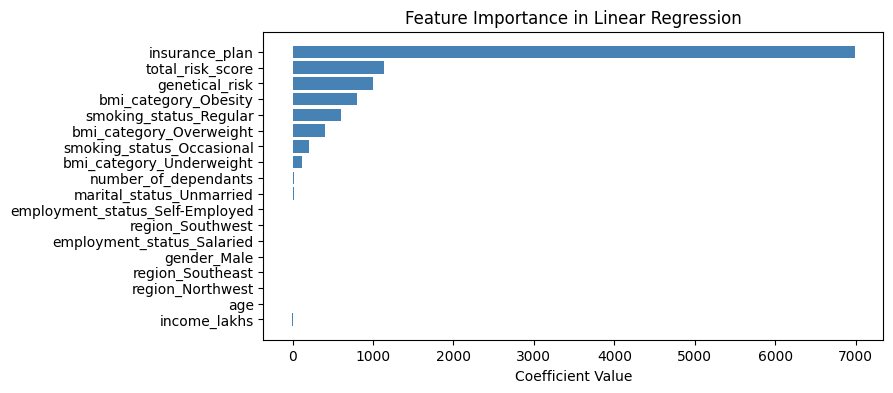

In [147]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_processed_final.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [148]:
from sklearn.linear_model import Ridge

model_reg = Ridge(alpha=1)

model_reg.fit(X_train_processed_final, y_train)

test_score = model_reg.score(X_test_processed, y_test)
train_score = model_reg.score(X_train_processed_final, y_train)
print(train_score, test_score)

y_pred = model_reg.predict(X_test_processed)
mse_reg = mean_squared_error(y_test, y_pred)
rmse_reg = np.sqrt(mse_lr)

mse_reg, rmse_reg

0.9884985406626117 0.9882597413296531


(89448.79221596352, np.float64(299.0647613019771))

In [149]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)

model_xgb.fit(X_train_processed_final, y_train)

model_xgb.fit(X_train_processed_final, y_train)
model_xgb.score(X_test_processed, y_test)

0.9872627258300781

In [150]:
y_pred = model_xgb.predict(X_test_processed)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)

mse_xgb, rmse_xgb

(97045.09375, np.float64(311.5206152889404))

In [151]:
model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train_processed_final, y_train)
random_search.best_score_

np.float64(0.9881292382876078)

In [152]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [153]:
best_model = random_search.best_estimator_

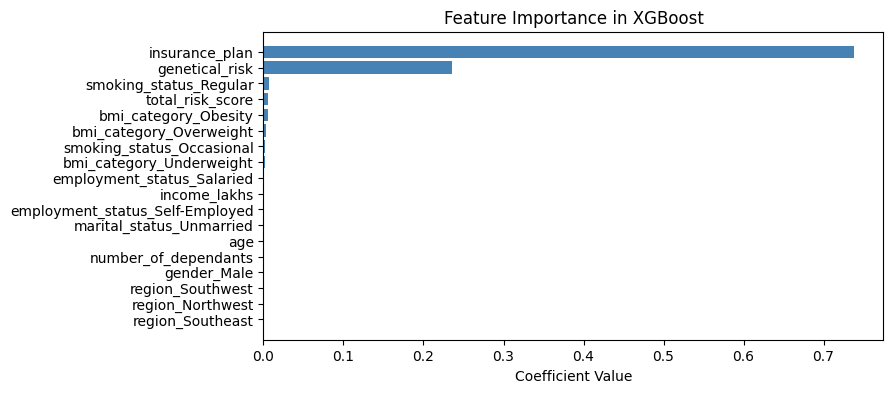

In [154]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_processed_final.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [155]:
y_pred = best_model.predict(X_test_processed)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
10489,5452,5459.750000,7.750000,0.142150
7989,9658,9034.060547,-623.939453,-6.460338
3113,6031,5777.926270,-253.073730,-4.196215
10605,12386,12143.197266,-242.802734,-1.960300
4204,4245,4701.327637,456.327637,10.749768


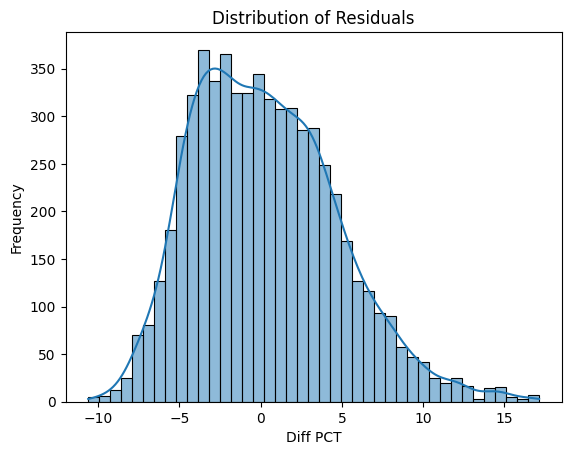

In [156]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [157]:
X_test_processed.shape

(6026, 18)

In [158]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
4204,4245,4701.327637,456.327637,10.749768
8862,4206,4635.344238,429.344238,10.207899
3396,4568,5068.031250,500.031250,10.946393
13142,4215,4704.776855,489.776855,11.619854
7802,4096,4538.517090,442.517090,10.803640


In [159]:
extreme_results_df.shape

(155, 4)

In [160]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

2.572187188848324

We have 2% extreme errors which means for 2% customers we will either overcharge or undercharge by 10% or more

In [161]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct


There will be about 0 customers whom we will overcharge or underchage by more than 50%

In [162]:
extreme_errors_df = X_test_processed.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,age,number_of_dependants,income_lakhs,total_risk_score,genetical_risk
4204,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.222222,0.0,0
8862,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.714286,0.333333,0.010101,0.0,0


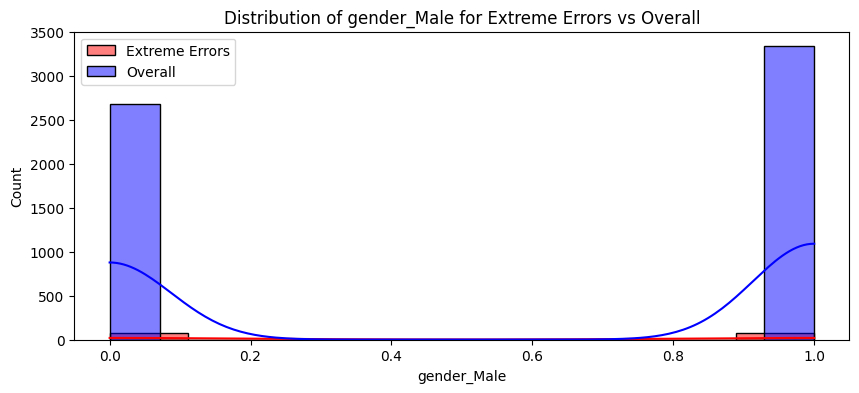

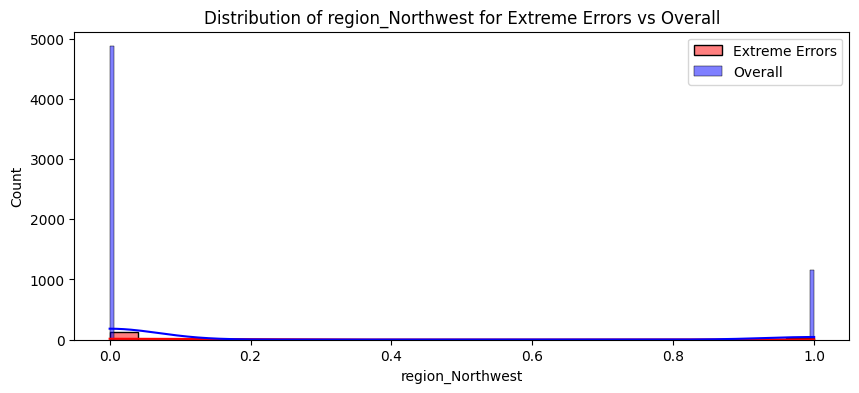

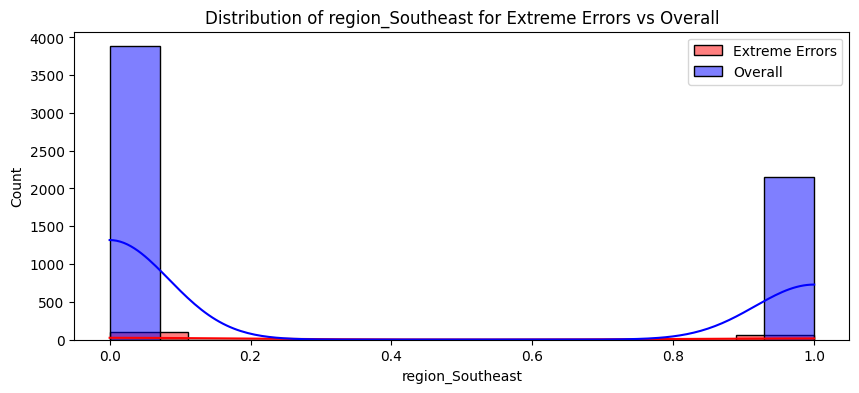

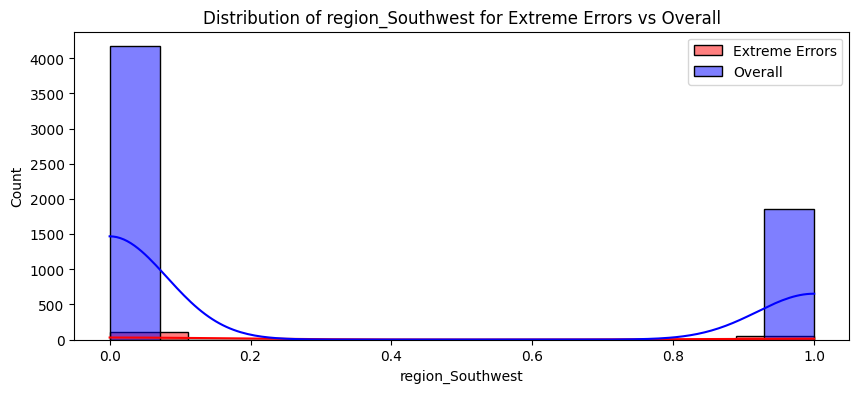

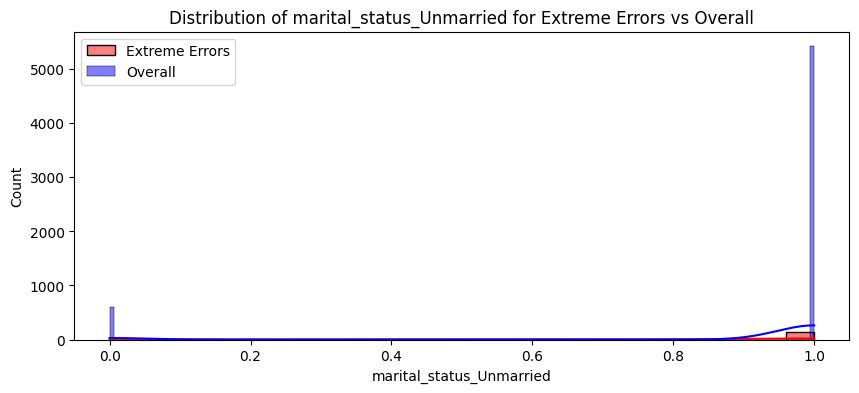

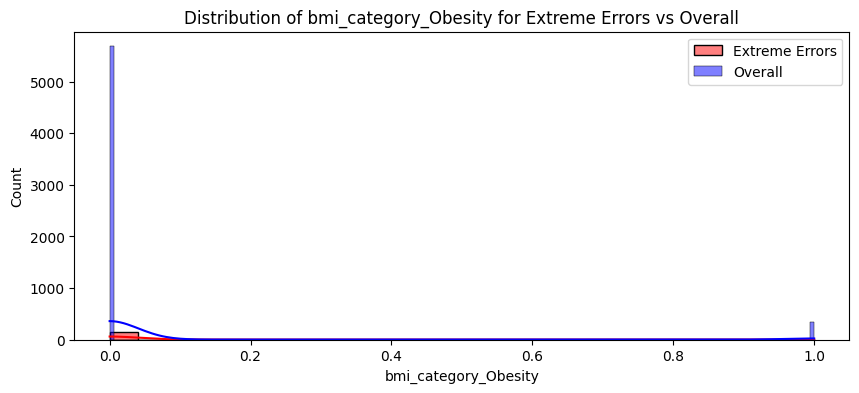

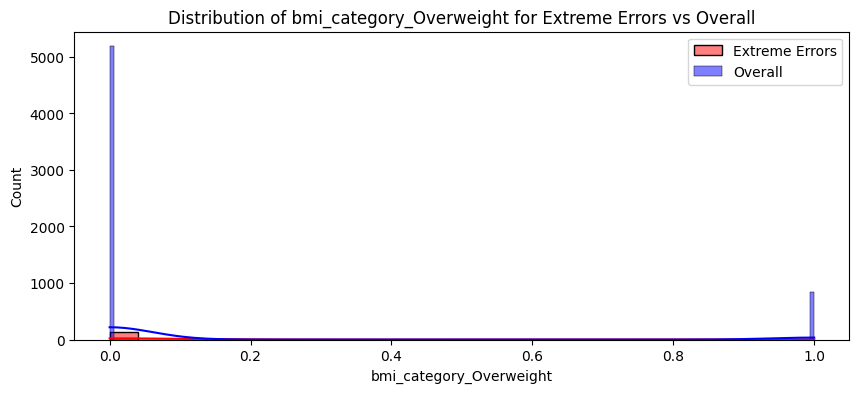

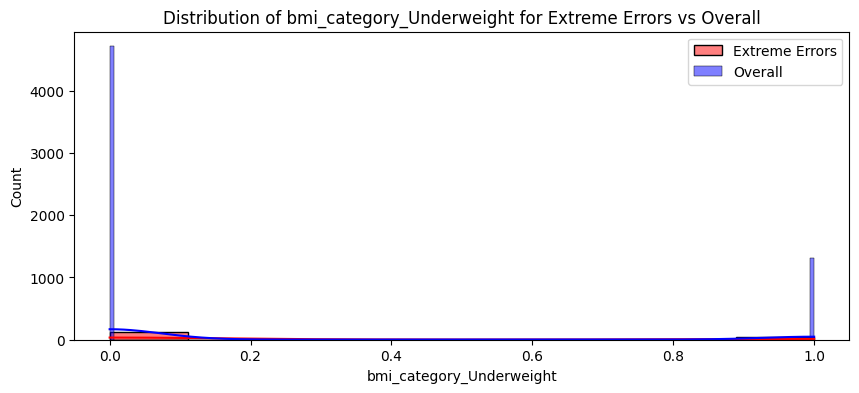

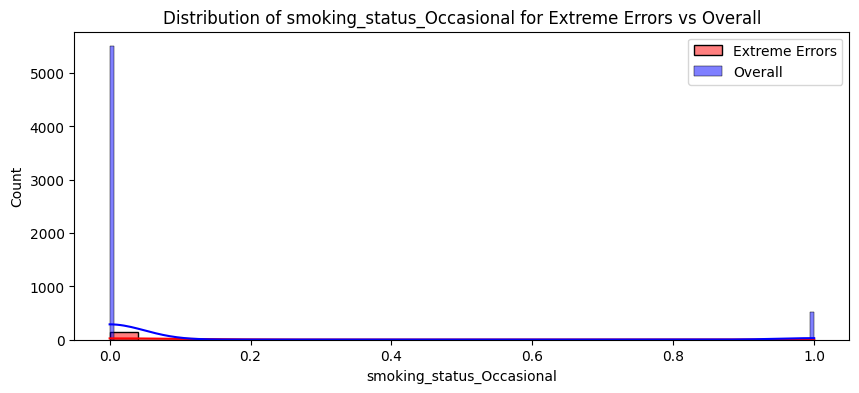

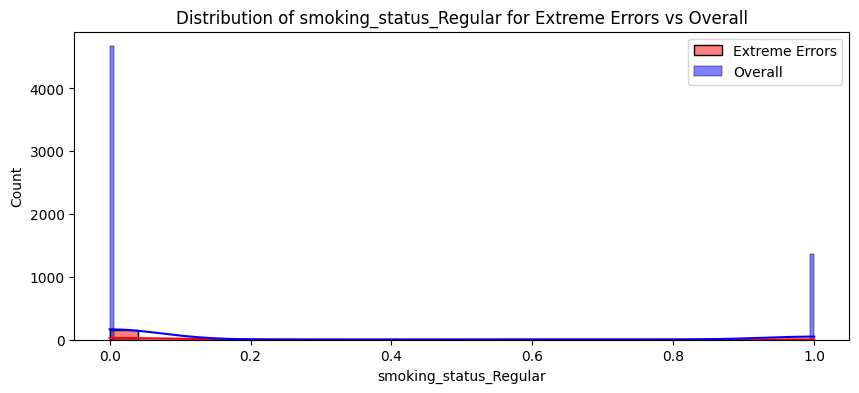

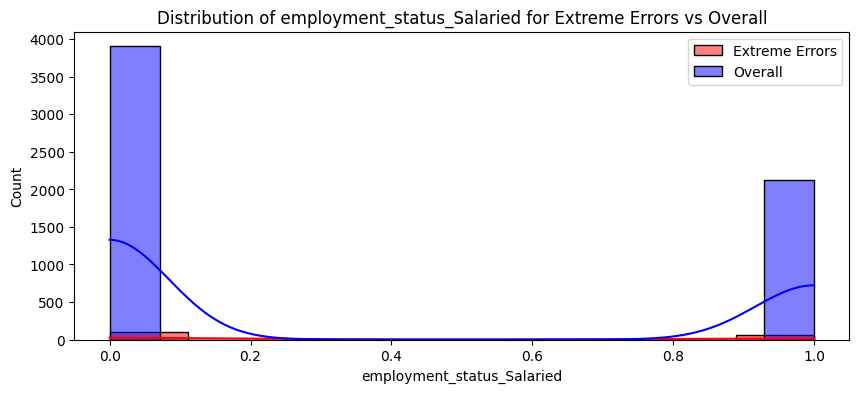

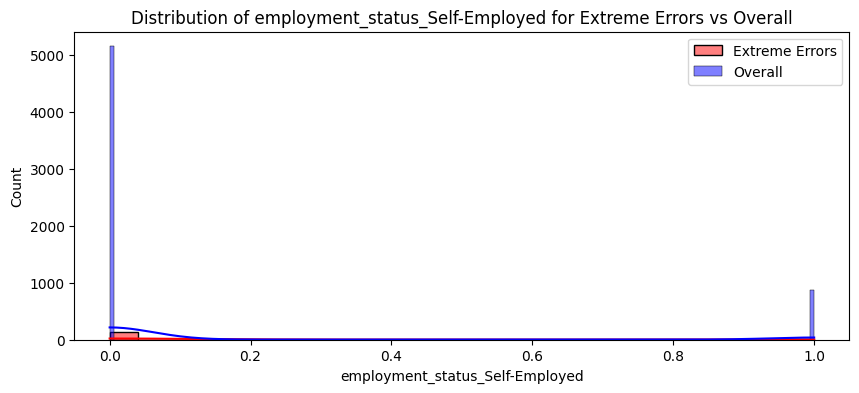

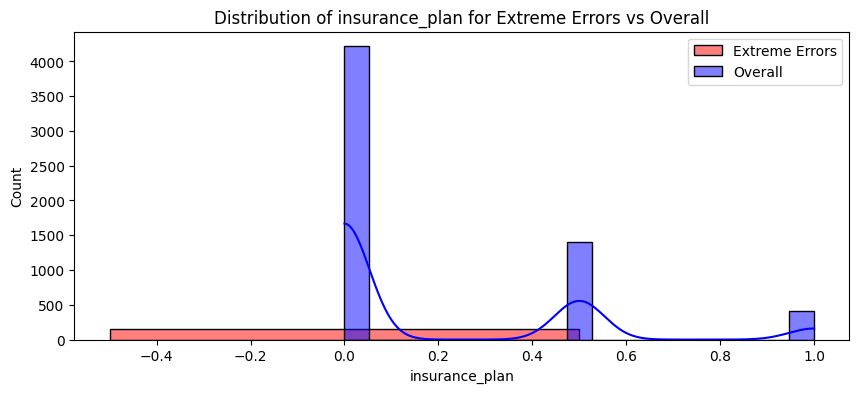

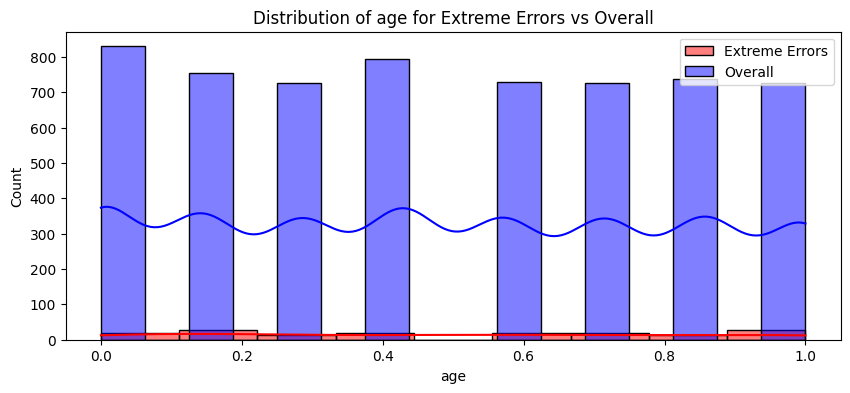

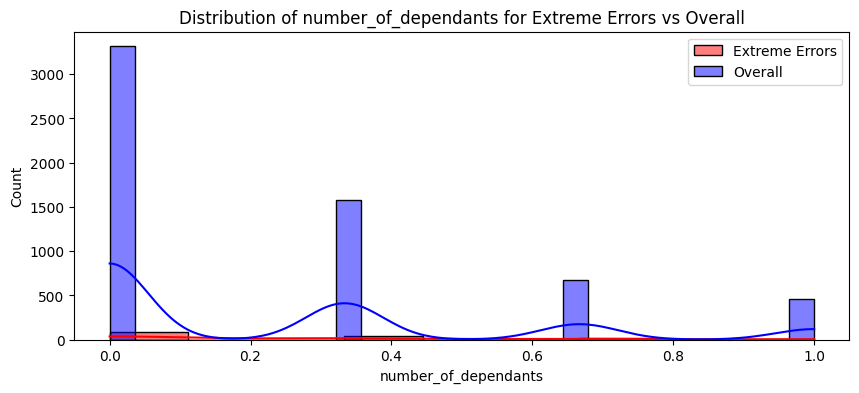

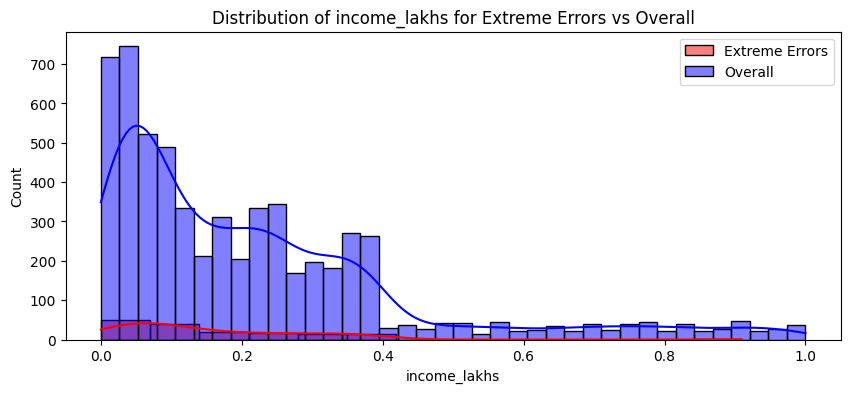

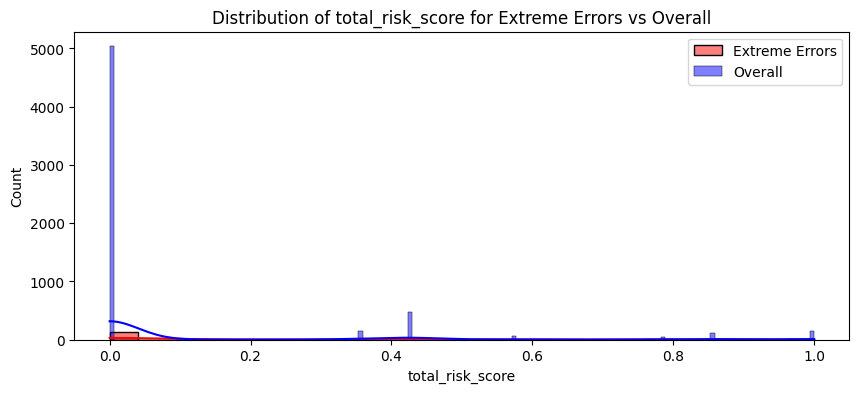

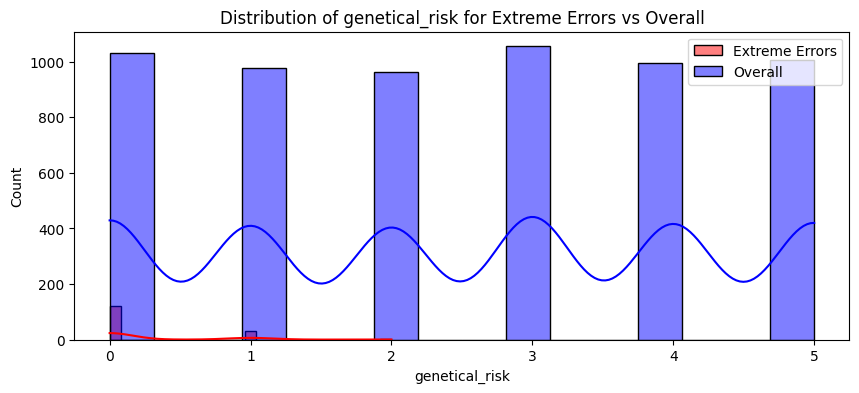

In [163]:
for feature in X_test_processed.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test_processed[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [164]:
extreme_errors_df['income_level']=-1

In [165]:
# Create a copy so you keep the rest of the columns intact
df_reversed = extreme_errors_df.copy()

# 1. Retrieve the fitted scaler from the ColumnTransformer
scaler = preprocessor.named_transformers_['numeric_scaler']

# 2. Inverse-transform only the numeric columns
df_reversed[numeric_cols] = scaler.inverse_transform(extreme_errors_df[numeric_cols])

df_reversed.head()

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed,insurance_plan,age,number_of_dependants,income_lakhs,total_risk_score,genetical_risk,income_level
4204,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,18.0,0.0,23.0,0.0,0,-1
8862,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,23.0,1.0,2.0,0.0,0,-1
3396,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,3.0,0.0,1,-1
13142,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,22.0,2.0,8.0,6.0,0,-1
7802,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,24.0,3.0,3.0,5.0,0,-1


<Axes: xlabel='age', ylabel='Count'>

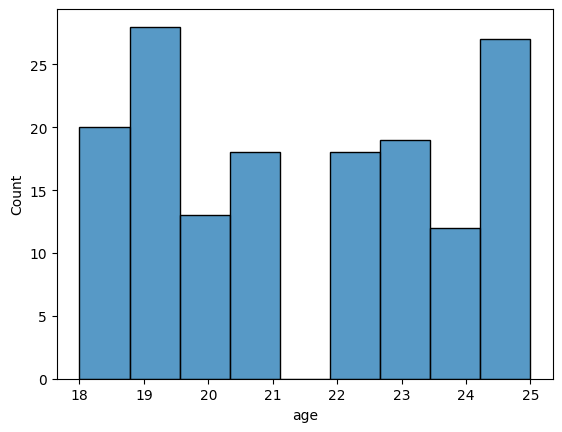

In [166]:
sns.histplot(df_reversed.age)

In [169]:
import os
from joblib import dump

# Ensure folder exists
os.makedirs("models", exist_ok=True)

# Save the preprocessor (handles all encoding + scaling + column tracking)
dump(preprocessor, "models/preprocessor_young.joblib")

# Save the trained model
dump(best_model, "models/model_young.joblib")

['models/model_young.joblib']